In [323]:
import numpy as np
from tqdm import tqdm 
import matplotlib.pyplot as plt

### Example using trasformation between cartesian coordinates $x$, $y$ and polar coordinates $r$, $\theta$

Distribucion en el espacio cartesiano: $p(\vec{X})$

Distribucion en el espacio de coordenadas polares: $p(\vec{\theta})$

$$p(\vec{X}) d\vec{X} = p(\vec{\theta}) d\vec{\theta}$$

$$p(\vec{X}) = p(\vec{\theta}) |\frac{d\vec{\theta}}{d\vec{X}}| $$

$$p(\vec{X}) = p(\vec{\theta}) \det(\mathbb{J}_{T_{\vec{\theta}} \vec{X}}) $$

\begin{equation}
    \mathbb{J}_{{T_{\vec{\theta}}} \vec{X}} \equiv 
    \begin{pmatrix} 
        \partial_xT_1 & \partial_yT_1 \\
        \partial_xT_2 & \partial_yT_2 
    \end{pmatrix}
\end{equation}

Sabemos 

$$x = r\cos(\theta)$$
$$y = r\sin(\theta)$$

En este caso necesitaremos la trasfromacion:
$$r = \sqrt{x^2 + y^2} = T_1$$
$$\theta = \tan^{-1}(y/x) = T_2$$

De modo que el Jacobiano nos queda

\begin{equation}
    \mathbb{J}_{{T_{\vec{\theta}}} \vec{X}} =
    \begin{pmatrix} 
        \frac{\partial}{\partial x} (\sqrt{x^2 + y^2}) & \frac{\partial}{\partial y} (\sqrt{x^2 + y^2}) \\
        \frac{\partial}{\partial x} (\tan^{-1}(y/x)) & \frac{\partial}{\partial y} (\tan^{-1}(y/x))
    \end{pmatrix}
    =
    \begin{pmatrix} 
        \frac{x}{\sqrt{x^2 + y^2}} & \frac{y}{\sqrt{x^2 + y^2}} \\
        -\frac{y}{x^2 + y^2}  & \frac{x}{x^2 + y^2} &
    \end{pmatrix}
\end{equation}

Para caclular el numero de valores que caen dentro de un volumen dx dy en el espacio cartesiano usamos la densidad de probabilidad $p(\vec{x})$
$$
N_{teo} \approx N_{gen} p(\vec{X}) dxdy 
$$

In [324]:
#genero un muestreo de puntos en el espacio polar 
N = int(1e7)

r_uniform = np.random.uniform(0, 1, N)
theta_uniform = np.random.uniform(0, 2*np.pi, N) 

#trasnformo a espacio cartesiano
x_uniform = r_uniform*np.cos(theta_uniform)
y_uniform = r_uniform*np.sin(theta_uniform)

vector_uniform = np.column_stack((x_uniform, y_uniform))

In [325]:
#defino el centro y el tamaño de la caja
x = 0.5
y = 0.5
center = (x,y)

delta_r = 0.5
delta_x = delta_r
delta_y = delta_r
dimensions = (delta_x, delta_y)

#masking para obtener los objetos dentro de la caja
objsx = (abs(x_uniform - center[0]) <= delta_x/2) 
objsy = (abs(y_uniform - center[1]) <= delta_y/2) 

objects = objsx * objsy
print('Numero de objetos en la caja: ', objects.sum())

Numero de objetos en la caja:  569725


In [326]:
#obtenemos vectores dentro de la caja
vector_in_box = vector_uniform[objects]
vector_in_box 

array([[0.39298326, 0.60561388],
       [0.34880619, 0.28305848],
       [0.40582082, 0.3616832 ],
       ...,
       [0.51800617, 0.40929074],
       [0.53510068, 0.5903763 ],
       [0.44583104, 0.73198507]], shape=(569725, 2))

In [327]:
#seleccionamos un objeto dentro de la caja para calcular el jacobiano
x_selected = vector_in_box[0,0]
y_selected = vector_in_box[0,1]

x_selected, y_selected

(np.float64(0.3929832559128435), np.float64(0.6056138791401502))

In [328]:
#calculamos el jacobiano 

jacobian = np.array([[x_selected/(x_selected**2 + y_selected**2)**0.5, y_selected/(x_selected**2 + y_selected**2)**0.5], [-y_selected/(x_selected**2 + y_selected**2), x_selected/(x_selected**2 + y_selected**2)]])
jacobian

array([[ 0.5443399 ,  0.83886475],
       [-1.16195169,  0.75399124]])

In [329]:
#calculamos el determinante del jacobiano

det = np.abs(np.linalg.det(jacobian))
det

np.float64(1.385147829376205)

Verificamos el jacobiano y su determinante usando la propiedad:

\begin{equation}
    \mathbb{J}_{T_{\vec{\theta}} \vec{X}} = \mathbb{J}^{-1}_{T_{\vec{X}} \vec{\theta}}
\end{equation}

Donde 

\begin{equation}
    \mathbb{J}_{{T_{\vec{X}}} \vec{\theta}} =
    \begin{pmatrix} 
        \frac{\partial}{\partial r} (r\cos{(\theta)}) & \frac{\partial}{\partial \theta} (r\cos{(\theta)}) \\
        \frac{\partial}{\partial r} (r\sin(\theta)) & \frac{\partial}{\partial \theta} (r\sin(\theta))
    \end{pmatrix}
    =
    \begin{pmatrix} 
        \cos(\theta) & -r\sin(\theta) \\
        \sin(\theta)  &  r\cos(\theta)
    \end{pmatrix}
\end{equation}

In [330]:
r_selected = (x_selected**2 + y_selected**2)**0.5
theta_selected = np.arctan2(y_selected, x_selected)

jacobian2 = np.array([[np.cos(theta_selected), -r_selected*np.sin(theta_selected)], [np.sin(theta_selected), r_selected*np.cos(theta_selected)]])
jacobian2

array([[ 0.5443399 , -0.60561388],
       [ 0.83886475,  0.39298326]])

In [331]:
jacobian, np.linalg.inv(jacobian2)

(array([[ 0.5443399 ,  0.83886475],
        [-1.16195169,  0.75399124]]),
 array([[ 0.5443399 ,  0.83886475],
        [-1.16195169,  0.75399124]]))

In [332]:
#calcuamos el volumen de la caja en el espacio cartesiano
Delta = delta_x*delta_y
Delta

0.25

In [333]:
#calculamos la distribucion del espacio polar, distribucion uniforme
r_max = 1
r_min = 0

theta_max = 2*np.pi
theta_min = 0

p_Polar = 1/(r_max - r_min) * 1/(theta_max - theta_min)
p_Polar

0.15915494309189535

In [334]:
#calculamos el numero de objetos en la caja en el espacio polar

print("Conteo de objetos dentro de la caja: ", objects.sum())
print("Numero de objetos calculados dentro de la caja: ", p_Polar * det * Delta * N)

Conteo de objetos dentro de la caja:  569725
Numero de objetos calculados dentro de la caja:  551132.8098955806


In [335]:
def number_objects_in_box(N: int, center: tuple, delta_r: float) -> tuple:
    #genero un muestreo de puntos en el espacio polar 

    r_uniform = np.random.uniform(0, 1, N)
    theta_uniform = np.random.uniform(0, 2*np.pi, N) 

    #trasnformo a espacio cartesiano
    x_uniform = r_uniform*np.cos(theta_uniform)
    y_uniform = r_uniform*np.sin(theta_uniform)

    delta_x = delta_r
    delta_y = delta_r

    #masking para obtener los objetos dentro de la caja
    objsx = (abs(x_uniform - center[0]) <= delta_x/2) 
    objsy = (abs(y_uniform - center[1]) <= delta_y/2) 

    objects = objsx * objsy

    x_in_box = x_uniform[objects]
    y_in_box = y_uniform[objects]

    return x_in_box[0], y_in_box[0], objects.sum()

In [336]:
def number_objects_calculated(x: float, y: float, delta_r: float, N: int, p_theta: float) -> float:
    jacobian = np.array([[x/(x**2 + y**2)**0.5, y/(x**2 + y**2)**0.5], [-y/(x**2 + y**2), x/(x**2 + y**2)]])
    det = np.abs(np.linalg.det(jacobian))

    delta_x = delta_r
    delta_y = delta_r
    
    Delta = delta_x*delta_y
    p_X = N * Delta * det * p_theta
    return p_X

In [337]:
vector_in_box 

array([[0.39298326, 0.60561388],
       [0.34880619, 0.28305848],
       [0.40582082, 0.3616832 ],
       ...,
       [0.51800617, 0.40929074],
       [0.53510068, 0.5903763 ],
       [0.44583104, 0.73198507]], shape=(569725, 2))

In [338]:
#variando el vector de objetos
from numpy import linspace

obj_in_box = objects.sum()
r_max = 1
r_min = 0
theta_max = 2*np.pi
theta_min = 0
p_theta = 1/(r_max - r_min) * 1/(theta_max - theta_min)
total_objects = np.linspace(0, 10, 100)

objs = []
for obj in tqdm(vector_in_box[:100]):
    x = obj[0]
    y = obj[1]
    objs.append(number_objects_calculated(x, y, delta_r, N, p_theta))

#variando el tamaño de la caja 

N = int(1e7)
x = 0.5
y = 0.5
center = (x,y)
deltas_r = np.linspace(0.01, 0.5, 10)

n_size = []
N_size = []
for deltas in tqdm(deltas_r):
    delta_r = deltas
    x, y, n = number_objects_in_box(N, center, delta_r)
    n_size.append(n)
    N_size.append(number_objects_calculated(x, y, delta_r, N, p_theta))

#variando el centro de la caja

centers = np.linspace(0., 0.5, 10)
delta_r = 0.1

n_center = []
N_center = []
for c in tqdm(centers):
    center = (c,c)
    x, y, n = number_objects_in_box(N, center, delta_r)
    n_center.append(n)
    N_center.append(number_objects_calculated(x, y, delta_r, N, p_theta))


#variando el numero de objetos
N_points = np.linspace(1e4, 1e8, 10)
x = 0.2
y = 0.2
center = (x,y)
delta_r = 0.2

n_objs = []
N_objs = []
for n in tqdm(N_points):
    N = int(n)
    x, y, n_objs_in_box = number_objects_in_box(N, center, delta_r)
    n_objs.append(n_objs_in_box)
    N_objs.append(number_objects_calculated(x, y, delta_r, N, p_theta))

100%|██████████| 10/10 [00:24<00:00,  2.42s/it]


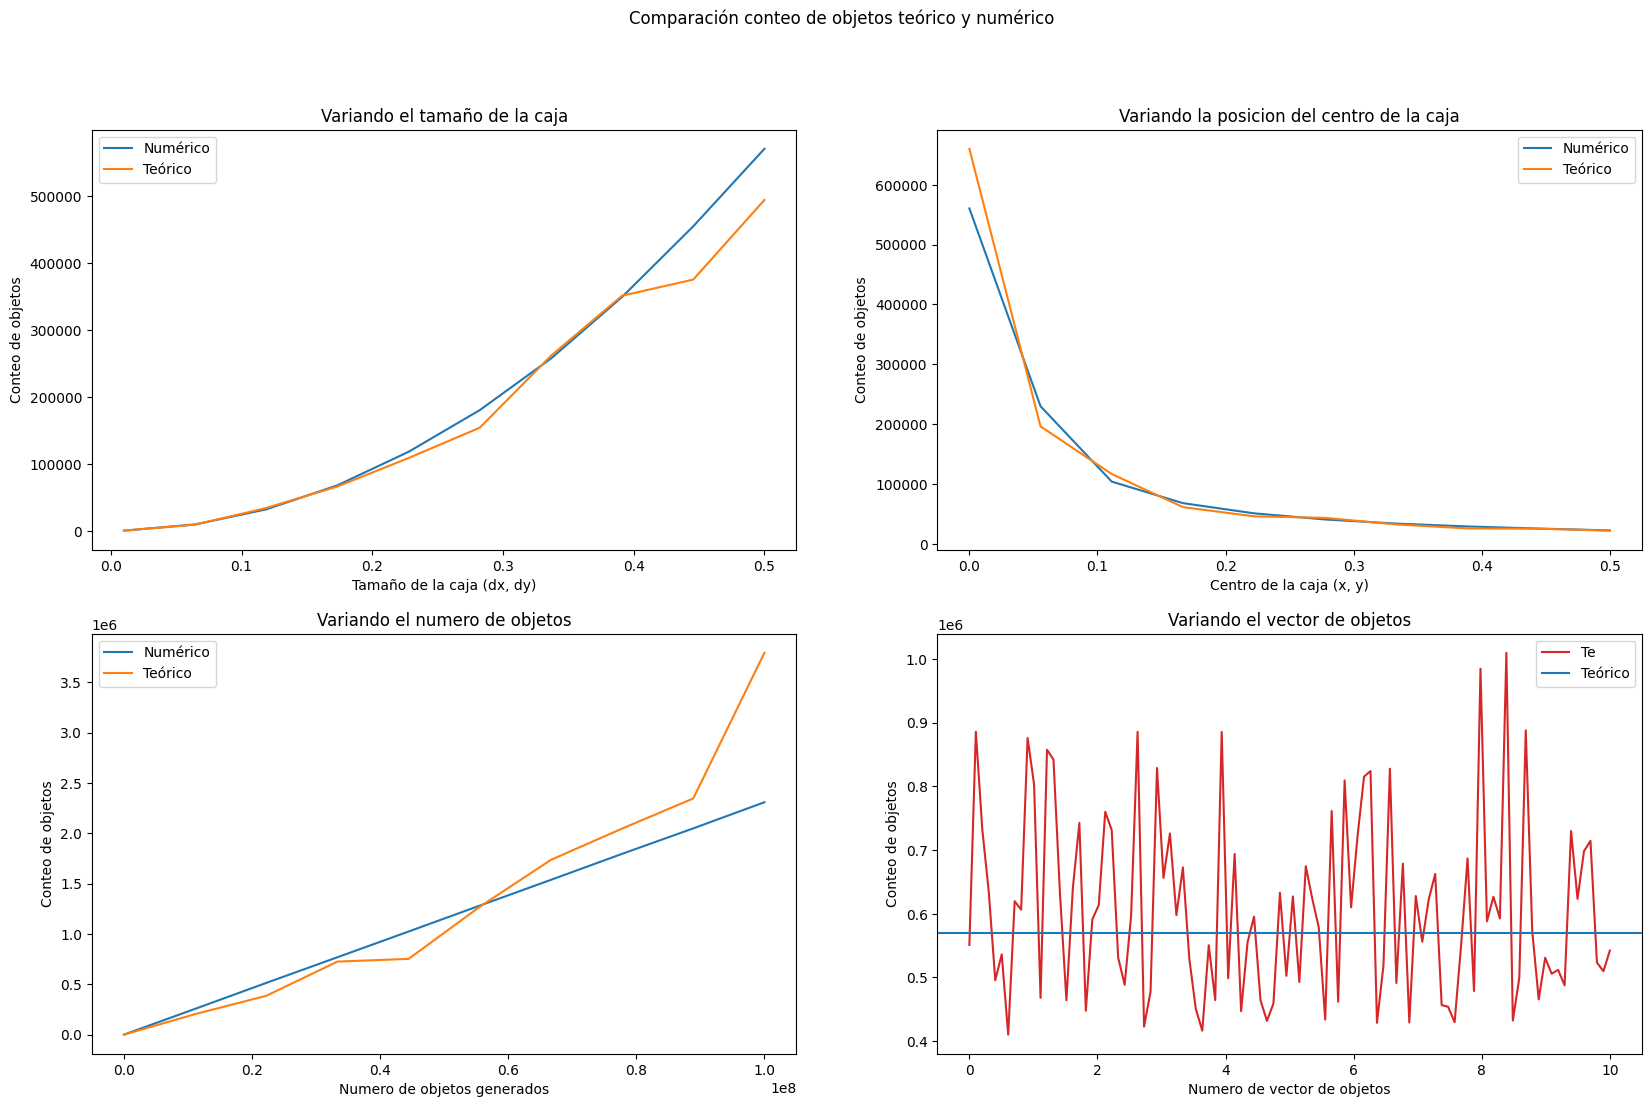

In [339]:
fig, axs = plt.subplots(2, 2, figsize=(20,12))
axs[0, 0].plot(deltas_r, n_size, label='Numérico')
axs[0, 0].plot(deltas_r, N_size, label='Teórico')
axs[0, 0].set_title('Variando el tamaño de la caja')
axs[0, 0].set_xlabel('Tamaño de la caja (dx, dy)')
axs[0, 0].set_ylabel('Conteo de objetos')
axs[0, 0].legend()

axs[0, 1].plot(centers, n_center, label='Numérico')
axs[0, 1].plot(centers, N_center, label='Teórico')
axs[0, 1].set_xlabel('Centro de la caja (x, y)')
axs[0, 1].set_ylabel('Conteo de objetos')
axs[0, 1].set_title('Variando la posicion del centro de la caja')
axs[0, 1].legend()      

axs[1, 0].plot(N_points, n_objs, label='Numérico')
axs[1, 0].plot(N_points, N_objs, label='Teórico')
axs[1, 0].set_xlabel('Numero de objetos generados')
axs[1, 0].set_ylabel('Conteo de objetos')
axs[1, 0].set_title('Variando el numero de objetos')
axs[1, 0].legend()

axs[1, 1].plot(total_objects, objs, 'tab:red', label='Te')
axs[1, 1].axhline(obj_in_box, label='Teórico')
axs[1, 1].set_xlabel('Numero de vector de objetos')
axs[1, 1].set_ylabel('Conteo de objetos')
axs[1, 1].set_title('Variando el vector de objetos')
axs[1, 1].legend()

plt.suptitle("Comparación conteo de objetos teórico y numérico")
plt.show();


### Trasformacion de esfericas a cartesianas 

$$ p(\vec{X}) d\vec{X} = p(\vec{\rho}) d\vec{\rho} $$
$$ p(\vec{X}) = p(\vec{\rho}) \frac{d\vec{\rho}}{d\vec{X}} $$
$$ p(\vec{X}) = p(\vec{\rho}) \det{(\mathbb{J}_{{T_{\vec{\rho}}} \vec{X}})} $$

\begin{equation}
    \mathbb{J}_{{T_{\vec{\rho}}} \vec{X}} \equiv 
    \begin{pmatrix} 
        \partial_xT_1 & \partial_yT_1 & \partial_zT_1\\
        \partial_xT_2 & \partial_yT_2 & \partial_zT_2\\
        \partial_xT_3 & \partial_yT_3 & \partial_zT_3
    \end{pmatrix}
\end{equation}

En este caso tenemos que la trasnformacion esta dada por 

$$ \rho = \sqrt{x^2 + y^2 + z^2} = T_1$$
$$ \theta = \tan^{-1}(y/x) = T_2$$
$$ \phi = \cos^{-1}(z/\sqrt{x^2 + y^2 + z^2}) = T_3$$

De esa forma el Jacobiano nos queda 

\begin{equation}
    \mathbb{J}_{{T_{\vec{\rho}}} \vec{X}} \equiv 
    \begin{pmatrix} 
        \frac{x}{\sqrt{x^2 + y^2 + z^2}} & \frac{y}{\sqrt{x^2 + y^2 + z^2}} & \frac{z}{\sqrt{x^2 + y^2 + z^2}}\\
        \frac{x z}{\sqrt{\frac{x^2 + y^2}{x^2 + y^2 +  z^2}} (x^2 + y^2 + z^2)^{3/2}} & \frac{y z}{\sqrt{\frac{x^2 + y^2}{x^2 + y^2 +  z^2}} (x^2 + y^2 + z^2)^{3/2}} & \frac{-x^2 - y^2}{\sqrt{\frac{x^2 + y^2}{x^2 + y^2 +  z^2}} (x^2 + y^2 + z^2)^{3/2}} \\
        -\frac{y}{x^2 + y^2} & \frac{x}{x^2 + y^2} & 0 
    \end{pmatrix}
\end{equation}


In [575]:
def J_rho_X(x, y, z):
    r = np.sqrt(x**2 + y**2 + z**2)
    rho_sq = x**2 + y**2
    rho_ratio = rho_sq / (x**2 + y**2 + z**2)
    denom = np.sqrt(rho_ratio) * r**3

    J = np.array([
        [x/r, y/r, z/r],
        [x*z/denom, y*z/denom, -rho_sq/denom],
        [-y/rho_sq, x/rho_sq, 0]
    ])

    return J

In [576]:
def jacobian_X_rho(r, theta, phi):
    
    J = np.array([
        [np.sin(phi) * np.cos(theta), r * np.cos(phi) * np.cos(theta), -r * np.sin(phi) * np.sin(theta)],
        [np.sin(phi) * np.sin(theta), r * np.cos(phi) * np.sin(theta),  r * np.sin(phi) * np.cos(theta)],
        [np.cos(phi),          -r * np.sin(phi),            0]
    ])
    
    return J

In [577]:
r = 2.0
theta = np.pi/4    
phi = np.pi/3 

x = r * np.sin(phi) * np.cos(theta)
y = r * np.sin(phi) * np.sin(theta)
z = r * np.cos(phi)

print(x, y, z)

1.2247448713915892 1.2247448713915892 1.0000000000000002


In [578]:
J_rho_X(x, y, z), jacobian_X_rho(r, theta, phi)

(array([[ 0.61237244,  0.61237244,  0.5       ],
        [ 0.1767767 ,  0.1767767 , -0.4330127 ],
        [-0.40824829,  0.40824829,  0.        ]]),
 array([[ 0.61237244,  0.70710678, -1.22474487],
        [ 0.61237244,  0.70710678,  1.22474487],
        [ 0.5       , -1.73205081,  0.        ]]))

In [579]:
np.linalg.inv(J_rho_X(x, y, z)), jacobian_X_rho(r, theta, phi)

(array([[ 0.61237244,  0.70710678, -1.22474487],
        [ 0.61237244,  0.70710678,  1.22474487],
        [ 0.5       , -1.73205081, -0.        ]]),
 array([[ 0.61237244,  0.70710678, -1.22474487],
        [ 0.61237244,  0.70710678,  1.22474487],
        [ 0.5       , -1.73205081,  0.        ]]))

In [580]:
N = int(10**7)

r = np.random.uniform(0, 1, N)
theta = np.random.uniform(0, 2*np.pi, N)
phi = np.random.uniform(0, np.pi, N)

x = r * np.sin(phi) * np.cos(theta)
y = r * np.sin(phi) * np.sin(theta)
z = r * np.cos(phi)

In [581]:
#defino el centro y el tamaño de la caja
x_center = 0
y_center = 0
z_center = 0

center = (x_center,y_center,z_center)

delta_r = 0.01
delta_x = delta_r
delta_y = delta_r
delta_z = delta_r
dimensions = (delta_x, delta_y, delta_z)

#masking para obtener los objetos dentro de la caja
objsx = (abs(x - center[0]) <= delta_x/2) 
objsy = (abs(y - center[1]) <= delta_y/2) 
objsz = (abs(z - center[2]) <= delta_z/2) 

objects = objsx * objsy * objsz
print('Numero de objetos en la caja: ', objects.sum())

Numero de objetos en la caja:  59410


In [582]:
selected_x = x[objects]
selected_y = y[objects]
selected_z = z[objects]

select_objects = np.column_stack((selected_x, selected_y, selected_z))
select_objects

array([[-1.36263880e-03, -1.73984243e-03, -3.73618832e-03],
       [-6.86481619e-04, -4.43388538e-05,  2.76386245e-04],
       [ 3.10715927e-05, -1.62842817e-05, -1.26340973e-05],
       ...,
       [-4.26039530e-04,  2.72982311e-04, -2.80502083e-03],
       [-2.30126857e-03,  1.46985213e-03, -3.96625037e-03],
       [-3.50863877e-04, -4.83154348e-04, -1.80701583e-03]],
      shape=(59410, 3))

In [583]:
x_vol = selected_x[0]
y_vol = selected_y[0]
z_vol = selected_z[0]

x_vol, y_vol, z_vol

(np.float64(-0.001362638802893921),
 np.float64(-0.001739842425810384),
 np.float64(-0.003736188318537412))

In [584]:
det = np.linalg.det(J_rho_X(x_vol, y_vol, z_vol))
det

np.float64(104242.57517501125)

In [585]:
Delta = delta_x * delta_y * delta_z
Delta

1.0000000000000002e-06

In [586]:
rho_max = 1
rho_min = 0
theta_max = 2*np.pi 
theta_min = 0
phi_max = np.pi
phi_min = 0

p_rho = 1/(rho_max - rho_min) * 1/(theta_max - theta_min) * 1/(phi_max - phi_min)
p_rho

0.05066059182116889

In [587]:
p_X_n = N * p_rho * det * Delta
p_X_n

np.float64(52809.905513287595)

In [588]:
#calculamos el numero de objetos en la caja en el espacio polar

print("Conteo de objetos dentro de la caja: ", objects.sum())
print("Numero de objetos calculados dentro de la caja: ", p_X_n)

Conteo de objetos dentro de la caja:  59410
Numero de objetos calculados dentro de la caja:  52809.905513287595


### Variacion numero de objetos dentro del volumen calculados 

In [589]:
def number_objects_in_box3D(N: int, center: tuple, delta_r: float) -> tuple:
    #genero un muestreo de puntos en el espacio esferico

    r_uniform = np.random.uniform(0, 1, N)
    theta_uniform = np.random.uniform(0, 2*np.pi, N)
    phi_uniform = np.random.uniform(0, np.pi, N)

    #trasnformo a espacio cartesiano
    x_uniform = r_uniform * np.sin(phi_uniform) * np.cos(theta_uniform)
    y_uniform = r_uniform * np.sin(phi_uniform) * np.sin(theta_uniform)
    z_uniform = r_uniform * np.cos(phi_uniform)

    delta_x = delta_r
    delta_y = delta_r
    delta_z = delta_r

    #masking para obtener los objetos dentro de la caja
    objsx = (abs(x_uniform - center[0]) <= delta_x/2) 
    objsy = (abs(y_uniform - center[1]) <= delta_y/2) 
    objsz = (abs(z_uniform - center[2]) <= delta_z/2) 

    objects = objsx * objsy * objsz

    x_in_box = x_uniform[objects]
    y_in_box = y_uniform[objects]
    z_in_box = z_uniform[objects]

    return x_in_box[0], y_in_box[0], z_in_box[0], objects.sum()

In [590]:
def number_objects_calculated3D(x: float, y: float, z: float, delta_r: float, N: int, p_rho: float) -> float:
    det = np.abs(np.linalg.det(J_rho_X(x, y, z)))

    delta_x = delta_r
    delta_y = delta_r
    delta_z = delta_r
    
    Delta = delta_x*delta_y*delta_z
    p_X = N * Delta * det * p_rho
    return p_X

In [607]:
N = int(1e7)
x = 0.5
y = 0.5
z = 0.5
center = (x,y,z)
delta_r = 0.05
x, y, z, n_objs = number_objects_in_box3D(N, center, delta_r)

r_max = 1
r_min = 0
theta_max = 2*np.pi
theta_min = 0
phi_max = np.pi
phi_min = 0
p_rho = 1/(r_max - r_min) * 1/(theta_max - theta_min) * 1/(phi_max - phi_min)
n_objs_calculated = number_objects_calculated3D(x, y, z, delta_r, N, p_rho)

print("Conteo de objetos dentro de la caja: ", n_objs)
print("Numero de objetos calculados dentro de la caja: ", n_objs_calculated)


Conteo de objetos dentro de la caja:  104
Numero de objetos calculados dentro de la caja:  103.26020863066874


In [608]:
select_objects[:50]

array([[-1.36263880e-03, -1.73984243e-03, -3.73618832e-03],
       [-6.86481619e-04, -4.43388538e-05,  2.76386245e-04],
       [ 3.10715927e-05, -1.62842817e-05, -1.26340973e-05],
       [ 3.92689545e-04,  2.72375414e-04,  2.73595460e-03],
       [-2.78121599e-05,  2.67771216e-05, -3.45572013e-04],
       [ 1.57006955e-03,  3.25542346e-03,  2.37949847e-03],
       [ 3.30198548e-03,  4.01311924e-03, -1.09852905e-03],
       [-3.91010190e-03, -2.00040669e-03, -1.40321925e-03],
       [-3.64922240e-04,  1.05631527e-04, -4.08528851e-03],
       [ 2.06785473e-03, -3.58153181e-03,  4.63766288e-03],
       [ 1.24612640e-04, -3.99987404e-04,  6.78609917e-04],
       [ 6.73037460e-04,  1.17735065e-03, -3.93119952e-03],
       [-1.96454954e-03,  6.28243075e-04, -1.52019430e-03],
       [ 6.51383880e-05,  4.11955868e-04, -5.29710261e-04],
       [ 9.99727383e-04,  1.25941252e-04,  1.36749605e-03],
       [-1.59430051e-03,  8.07571025e-04,  4.75698244e-04],
       [-3.13407937e-03, -1.61879424e-03

In [625]:
obj_in_box = objects.sum()
delta_r = 0.01

r_max = 1
r_min = 0
theta_max = 2*np.pi
theta_min = 0
phi_max = np.pi
phi_min = 0
p_rho = 1/(r_max - r_min) * 1/(theta_max - theta_min) * 1/(phi_max - phi_min)
total_objects = np.linspace(0, 50, 50)

objs = []
for obj in tqdm(select_objects[:50]):
    x = obj[0]
    y = obj[1]
    z = obj[2]
    objs.append(number_objects_calculated3D(x, y, z, delta_r, N, p_rho))

#variando el tamaño de la caja 

N = int(1e7)
x = 0.1
y = 0.1
z = 0.1
center = (x,y,z)
deltas_r = np.linspace(0.01, 0.5, 10)

n_size = []
N_size = []
for deltas in tqdm(deltas_r):
    delta_r = deltas
    x, y, z, n = number_objects_in_box3D(N, center, delta_r)
    n_size.append(n)
    N_size.append(number_objects_calculated3D(x, y, z, delta_r, N, p_rho))

#variando el centro de la caja

centers = np.linspace(0., 0.5, 10)
delta_r = 0.05

n_center = []
N_center = []
for c in tqdm(centers):
    center = (c,c,c)
    x, y, z, n = number_objects_in_box3D(N, center, delta_r)
    n_center.append(n)
    N_center.append(number_objects_calculated3D(x, y, z, delta_r, N, p_rho))


#variando el numero de objetos
N_points = np.linspace(1e4, 1e8, 10)
x = 0.1
y = 0.1
z = 0.1
center = (x,y,z)
delta_r = 0.05

n_objs = []
N_objs = []
for n in tqdm(N_points):
    N = int(n)
    x, y, z, n_objs_in_box = number_objects_in_box3D(N, center, delta_r)
    n_objs.append(n_objs_in_box)
    N_objs.append(number_objects_calculated3D(x, y, z, delta_r, N, p_rho))

100%|██████████| 10/10 [00:50<00:00,  5.00s/it]


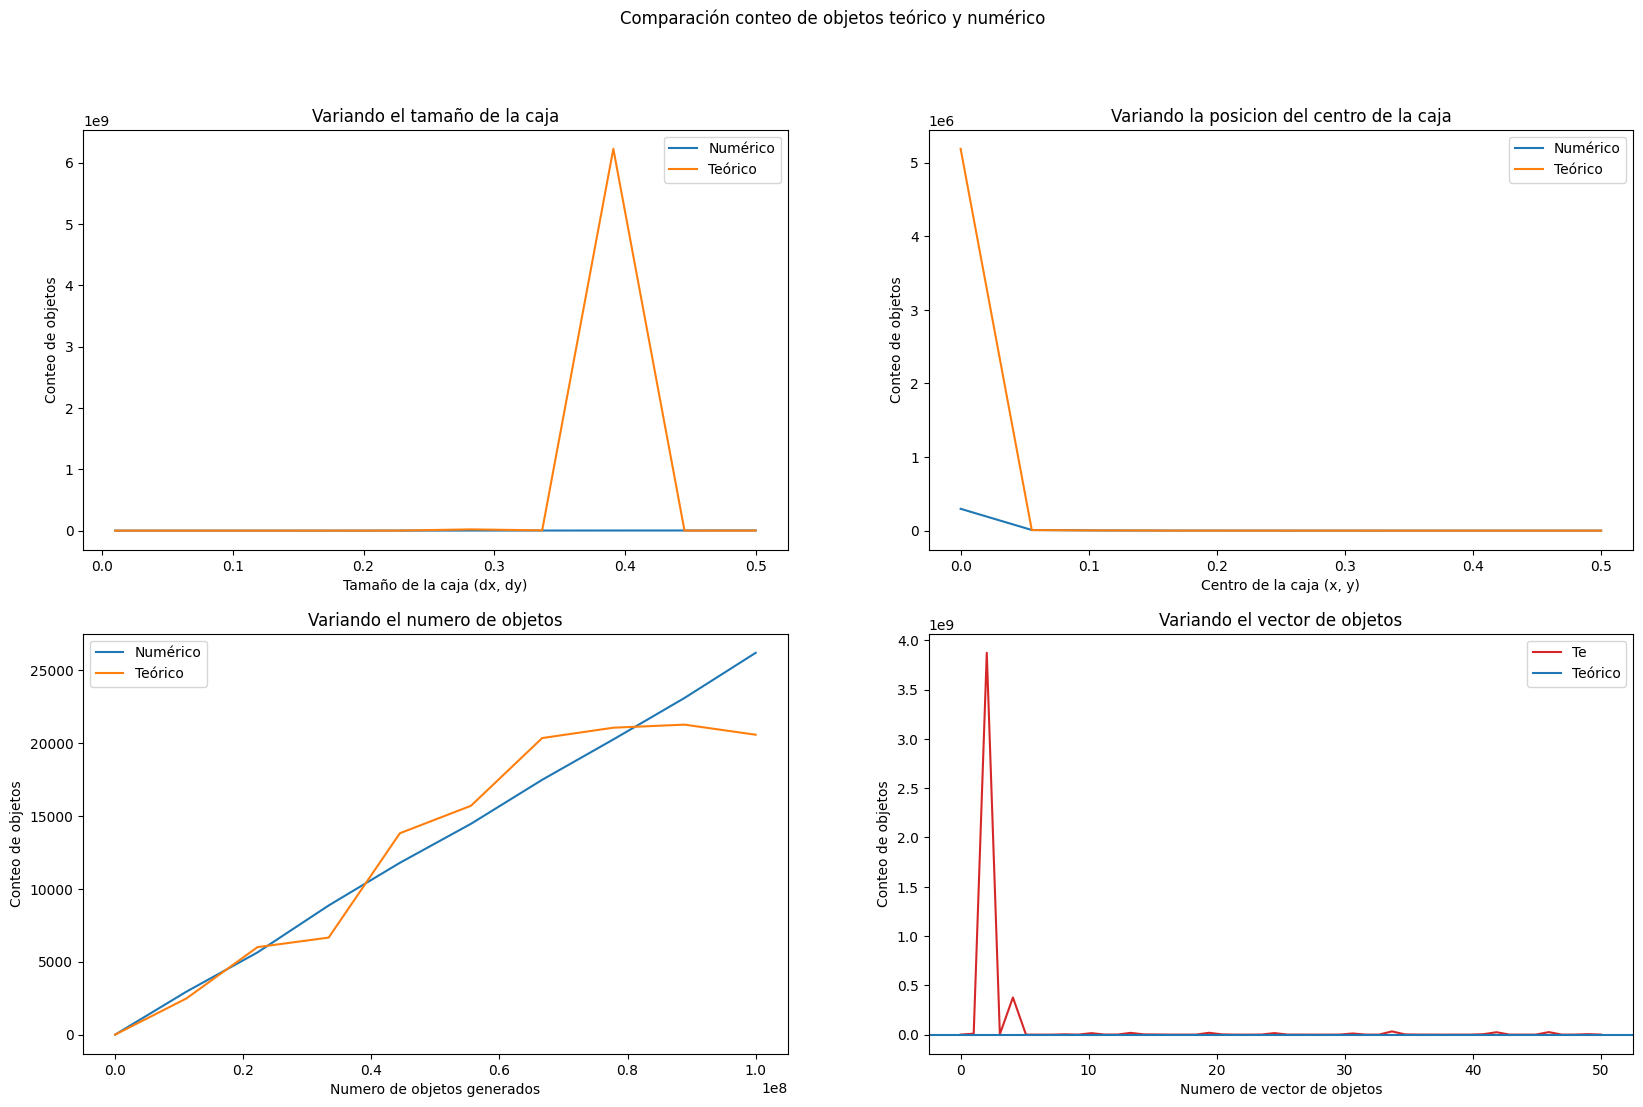

In [626]:
fig, axs = plt.subplots(2, 2, figsize=(20,12))
axs[0, 0].plot(deltas_r, n_size, label='Numérico')
axs[0, 0].plot(deltas_r, N_size, label='Teórico')
axs[0, 0].set_title('Variando el tamaño de la caja')
axs[0, 0].set_xlabel('Tamaño de la caja (dx, dy)')
axs[0, 0].set_ylabel('Conteo de objetos')
axs[0, 0].legend()

axs[0, 1].plot(centers, n_center, label='Numérico')
axs[0, 1].plot(centers, N_center, label='Teórico')
axs[0, 1].set_xlabel('Centro de la caja (x, y)')
axs[0, 1].set_ylabel('Conteo de objetos')
axs[0, 1].set_title('Variando la posicion del centro de la caja')
axs[0, 1].legend()      

axs[1, 0].plot(N_points, n_objs, label='Numérico')
axs[1, 0].plot(N_points, N_objs, label='Teórico')
axs[1, 0].set_xlabel('Numero de objetos generados')
axs[1, 0].set_ylabel('Conteo de objetos')
axs[1, 0].set_title('Variando el numero de objetos')
axs[1, 0].legend()

axs[1, 1].plot(total_objects, objs, 'tab:red', label='Te')
axs[1, 1].axhline(obj_in_box, label='Teórico')
axs[1, 1].set_xlabel('Numero de vector de objetos')
axs[1, 1].set_ylabel('Conteo de objetos')
axs[1, 1].set_title('Variando el vector de objetos')
axs[1, 1].legend()

plt.suptitle("Comparación conteo de objetos teórico y numérico")
plt.show();


In [676]:
N_size_filtered = np.array(N_size)[np.array(N_size) < 10**7]
n_size_filtered = np.array(n_size)[np.array(N_size) < 10**7]
deltas_r_filtered = deltas_r[np.array(N_size) < 10**7]

objs_filtered = np.array(objs)[np.array(objs) < 10**7]
total_objects_filtered = np.array(total_objects)[np.array(objs) < 10**7]

n_center_filtered = np.array(n_center)[np.array(N_center) < 10**6]
N_center_filtered = np.array(N_center)[np.array(N_center) < 10**6]
centers_filtered = centers[np.array(N_center) < 10**6]



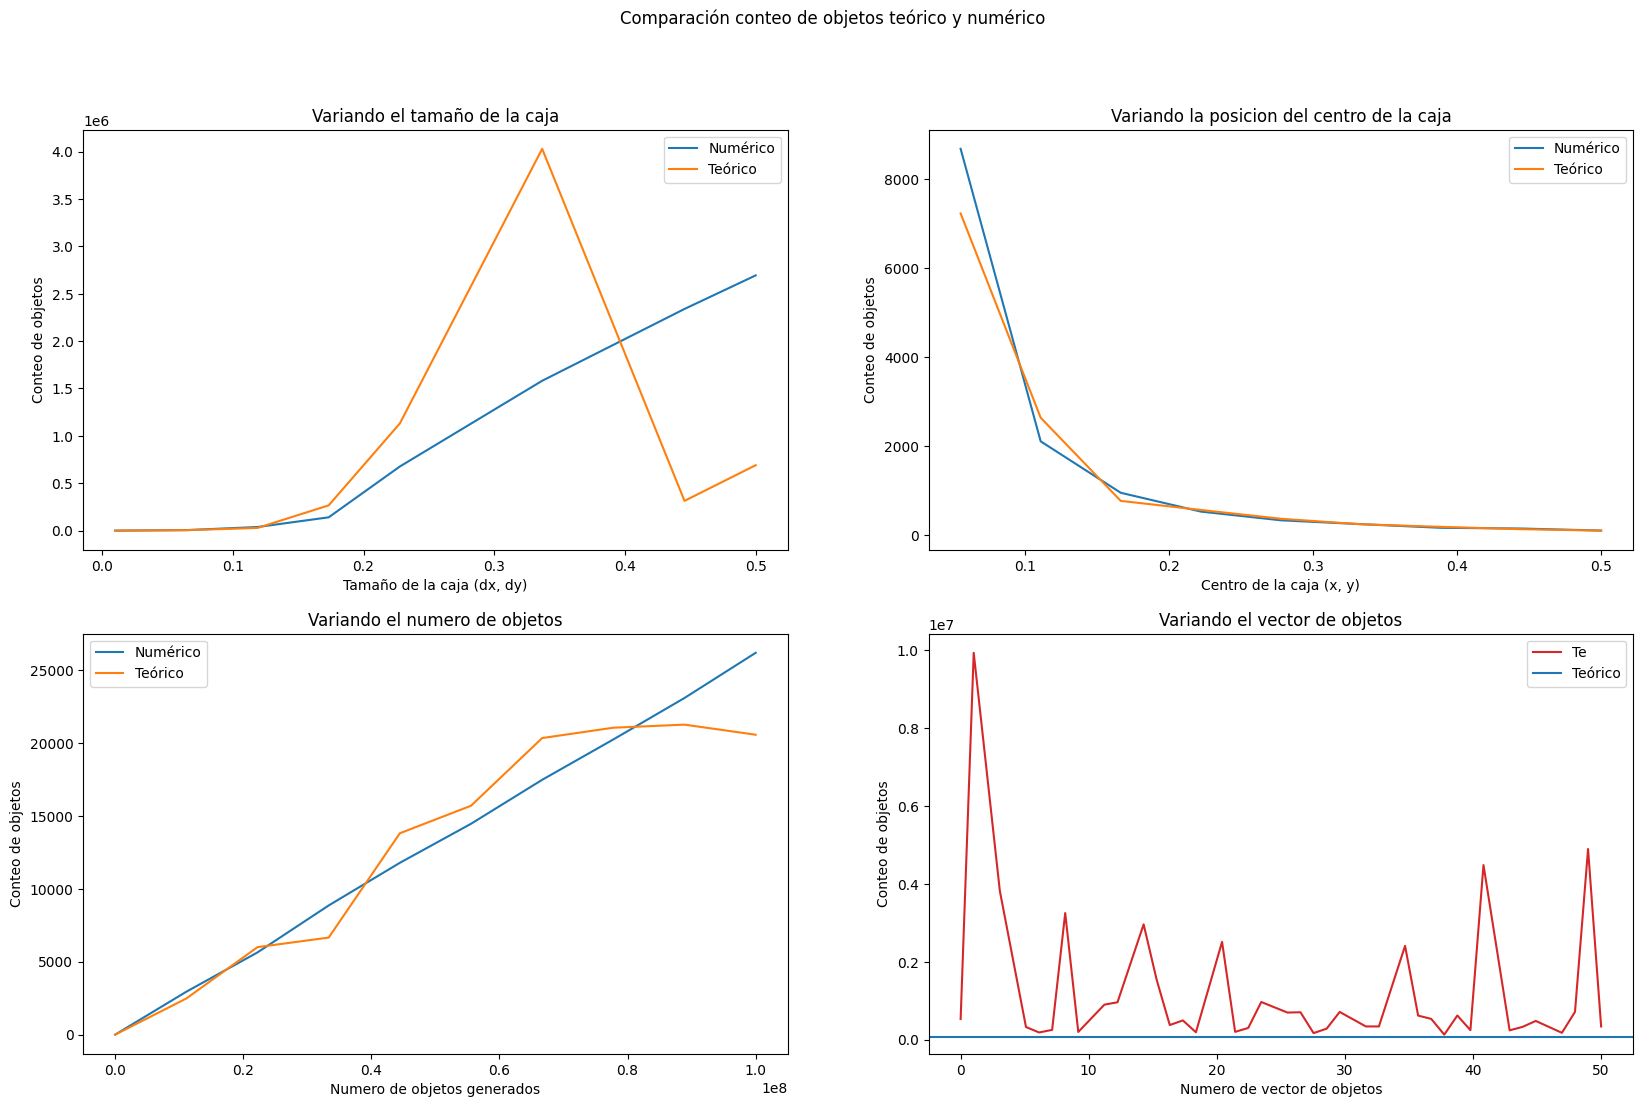

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(20,12))
axs[0, 0].plot(deltas_r_filtered, n_size_filtered, label='Numérico')
axs[0, 0].plot(deltas_r_filtered, N_size_filtered, label='Teórico')
axs[0, 0].set_title('Variando el tamaño de la caja')
axs[0, 0].set_xlabel('Tamaño de la caja (dx, dy)')
axs[0, 0].set_ylabel('Conteo de objetos')
axs[0, 0].legend()

axs[0, 1].plot(centers_filtered, n_center_filtered, label='Numérico')
axs[0, 1].plot(centers_filtered, N_center_filtered, label='Teórico')
axs[0, 1].set_xlabel('Centro de la caja (x, y)')
axs[0, 1].set_ylabel('Conteo de objetos')
axs[0, 1].set_title('Variando la posicion del centro de la caja')
axs[0, 1].legend()      

axs[1, 0].plot(N_points, n_objs, label='Numérico')
axs[1, 0].plot(N_points, N_objs, label='Teórico')
axs[1, 0].set_xlabel('Numero de objetos generados')
axs[1, 0].set_ylabel('Conteo de objetos')
axs[1, 0].set_title('Variando el numero de objetos')
axs[1, 0].legend()

axs[1, 1].plot(total_objects_filtered, objs_filtered, 'tab:red', label='Teorico')
axs[1, 1].axhline(obj_in_box, label='Numerico')
axs[1, 1].set_xlabel('Numero de vector de objetos')
axs[1, 1].set_ylabel('Conteo de objetos')
axs[1, 1].set_title('Variando el vector de objetos')
axs[1, 1].legend()

plt.suptitle("Comparación conteo de objetos teórico y numérico")
plt.show();